# Module 09 — Capstone: Guardian of the Grid  (worked solution)

You are a dynamical-systems analyst on call for a grid operator. Generator **G4** has been
showing erratic frequency swings, and last week a sister unit suffered an unexplained
**blackout** during a slow load increase. Two data logs landed on your desk. Management wants
three questions answered, fast:

1. **Is G4's frequency wobble deterministic** (a controllable nonlinear instability) **or just
   random noise?**
2. **How much safety margin does a synchronized generator actually have** — and what does
   "losing sync" look like in state space?
3. **Could the sister unit's blackout have been seen coming**, and where exactly is the point
   of no return?

The physics is the **swing equation** — a single synchronous machine tied to a large grid,
mathematically a *driven damped pendulum* (single-machine-infinite-bus, SMIB):

$$\dot\delta = \omega, \qquad \dot\omega = P + A\cos(\Omega t) - \alpha\,\omega - K\sin\delta .$$

This is *the* textbook complex-systems tipping problem, and it exercises the whole `tsdynamics`
stack: delay embedding, correlation dimension, Lyapunov-from-data, surrogates, RQA (Module 04/05);
custom systems, fixed points, stroboscopic sections (Module 02/06); basins, basin stability,
resilience, continuation and tipping points (Module 07); plus early-warning signals.

**You will learn to:**
- Diagnose *deterministic chaos vs. noise* in a single measured channel, end to end.
- Turn a data model into a mechanistic model and read its **map of safety** (basins).
- Detect **critical slowing down** and locate a **saddle-node fold** as the point of no return.
- Deliver an operator-facing **verdict** grounded in numbers, not vibes.

*Estimated time: 25–35 min.*

In [1]:
# Colab/first-run setup: install the workshop stack if tsdynamics is missing.
try:
    import tsdynamics  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "tsdynamics[viz,interactive]==5.3.1", "matplotlib", "plotly", "pandas"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import tsdynamics as ts
print("tsdynamics", ts.__version__)

tsdynamics 5.3.1


In [2]:
# Shared imports for the capstone: pandas for the logs + the mechanistic grid model.
import sys
import pandas as pd
sys.path.insert(0, "/home/elessar/Projects/tsdynamics-workshop/capstone")
from grid_model import (
    GridNode, NoisyGridNode, delta_star, critical_load, leading_eigenvalue,
)
from tsdynamics.data import Box, Grid

DATA = "/home/elessar/Projects/tsdynamics-workshop/capstone/data"
ASSETS = "/home/elessar/Projects/tsdynamics-workshop/assets/img"

# GridNode is parametrized with a params dict (or .with_params); K = 1.0 is the line limit.
print("Fold load  P_c = K =", critical_load())
print("Sync angle at P=0.4:  delta* =", round(delta_star(0.4), 4), "rad")

Fold load  P_c = K = 1.0
Sync angle at P=0.4:  delta* = 0.4115 rad


---
## Act I — Diagnosis: chaos or noise?

We have a single scalar channel — G4's rotor **frequency deviation** `freq_dev` (rad/s),
sampled at `dt = 0.2 s`. Nothing about the underlying state space is given. Our job is to
decide whether this is *low-dimensional deterministic chaos* (a controllable instability of a
few degrees of freedom) or *irreducible random noise*. We attack it with the full nonlinear
time-series toolbox.

4000 samples, dt = 0.2 s, span = 800 s
freq_dev range: [-2.33, 3.27] rad/s


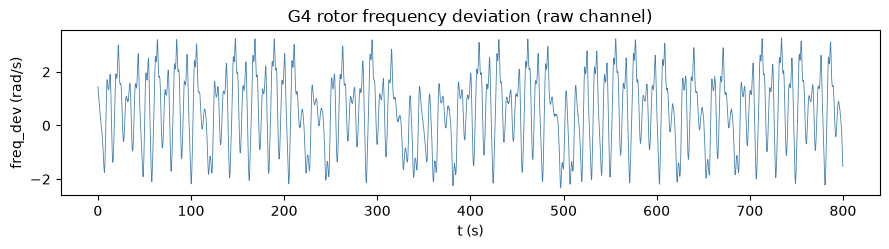

In [3]:
# Load the SCADA telemetry. The header has multi-line "#" comments -> comment="#".
scada = pd.read_csv(f"{DATA}/scada_stream.csv", comment="#")
t_scada = scada["t"].values
freq = scada["freq_dev"].values
DT = 0.20
print(f"{len(freq)} samples, dt = {DT} s, span = {t_scada[-1]:.0f} s")
print(f"freq_dev range: [{freq.min():.2f}, {freq.max():.2f}] rad/s")

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(t_scada, freq, lw=0.6, color="steelblue")
ax.set(xlabel="t (s)", ylabel="freq_dev (rad/s)", title="G4 rotor frequency deviation (raw channel)")
fig.tight_layout()
plt.show()

The trace looks erratic but *bounded* — it never runs away. That is already a hint: pure noise
would not confine itself to a strange-attractor-shaped region. Let's reconstruct the attractor.

### Delay embedding (Takens)

With one channel we reconstruct the state space by **delay coordinates**
$\mathbf{y}(t) = (x_t, x_{t-\tau}, x_{t-2\tau}, \dots)$. We pick the delay $\tau$ from the first
minimum of the mutual information, and the embedding dimension $m$ from Cao's method.

In [4]:
from tsdynamics.analysis.embedding import optimal_delay, embedding_dimension, embed

tau = int(optimal_delay(freq).value)            # first mutual-information minimum (in samples)
m = int(embedding_dimension(freq, delay=tau, max_dim=10).dimension)   # Cao's method
print(f"optimal delay  tau = {tau} samples  ({tau * DT:.1f} s)")
print(f"embedding dim  m   = {m}   (low -> a few degrees of freedom)")

Y3 = np.asarray(embed(freq, dimension=3, delay=tau))   # 3-D for a look
print("reconstructed cloud shape:", Y3.shape)

optimal delay  tau = 12 samples  (2.4 s)
embedding dim  m   = 5   (low -> a few degrees of freedom)
reconstructed cloud shape: (3976, 3)


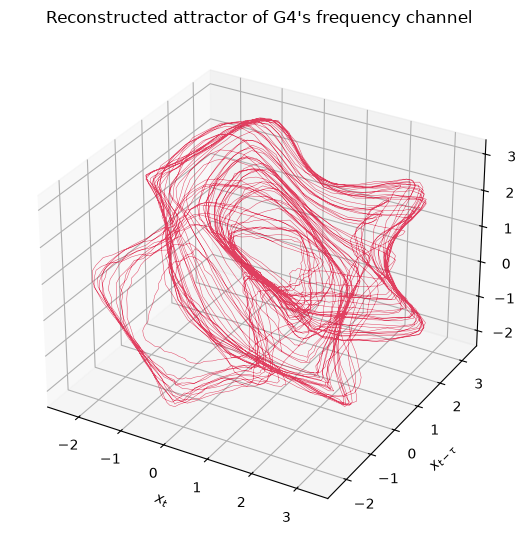

In [5]:
# Plot the reconstructed attractor — if it has structure, it is not a fuzzball.
fig = plt.figure(figsize=(6.5, 5.5))
ax = fig.add_subplot(111, projection="3d")
ax.plot(Y3[:, 0], Y3[:, 1], Y3[:, 2], lw=0.35, color="crimson", alpha=0.8)
ax.set(xlabel=r"$x_t$", ylabel=r"$x_{t-\tau}$", zlabel=r"$x_{t-2\tau}$")
ax.set_title("Reconstructed attractor of G4's frequency channel")
fig.tight_layout()
plt.show()

A folded, sheet-like object with clear structure — the fingerprint of a **low-dimensional
deterministic attractor**, not a random blob. Now let's put a number on "low-dimensional".

### Correlation dimension $D_2$

Grassberger–Procaccia: the correlation sum $C(r)\sim r^{D_2}$ over a scaling range of radii.
A *low* $D_2$ means the dynamics live on a thin fractal set — a few active degrees of freedom.

In [6]:
Ym = np.asarray(embed(freq, dimension=m, delay=tau))       # full m-dim embedding
D2 = ts.correlation_dimension(Ym, radii=np.logspace(-1.0, 0.8, 20)).value
print(f"correlation dimension  D2 = {D2:.2f}")
print("=> a low-dimensional attractor (D2 ~ 2, not tens or hundreds).")

correlation dimension  D2 = 2.17
=> a low-dimensional attractor (D2 ~ 2, not tens or hundreds).


### Largest Lyapunov exponent from data (Kantz)

The definitive chaos test: do nearby trajectories **diverge exponentially**? Kantz (1994)
tracks the average log-divergence $S(k)$ of neighbours; a straight, positive-slope segment is a
positive Lyapunov exponent. We plot $S(k)$ first, choose the linear scaling window, then fit.

lambda_1 = 0.083 / s   (positive => chaos)
Lyapunov time  1/lambda_1 = 12.1 s (predictability horizon of ~12 s)


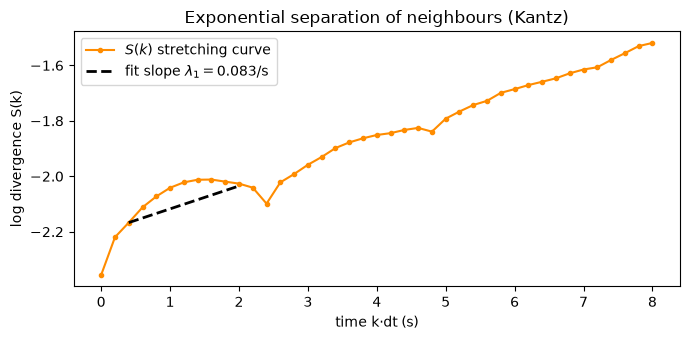

In [7]:
L = ts.lyapunov_from_data(freq, dt=DT, dimension=4, delay=tau, k_max=40,
                          method="kantz", fit=(2, 10))
lam1 = L.value
print(f"lambda_1 = {lam1:.3f} / s   (positive => chaos)")
print(f"Lyapunov time  1/lambda_1 = {1.0 / lam1:.1f} s "
      f"(predictability horizon of ~{1.0 / lam1:.0f} s)")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(L.times, L.divergence, "o-", ms=3, color="darkorange", label=r"$S(k)$ stretching curve")
# overlay the fitted linear region
lo, hi = 2, 10
tt = L.times[lo:hi + 1]
ax.plot(tt, L.divergence[lo] + lam1 * (tt - tt[0]), "k--", lw=2,
        label=fr"fit slope $\lambda_1={lam1:.3f}$/s")
ax.set(xlabel="time k·dt (s)", ylabel="log divergence S(k)",
       title="Exponential separation of neighbours (Kantz)")
ax.legend()
fig.tight_layout()
plt.show()

The stretching curve climbs *linearly* over the fitted window — unambiguous exponential
divergence with $\lambda_1 \approx 0.08$/s. A Lyapunov time of ~12 s means the wobble is
*predictable short-term but not long-term*: the hallmark of chaos, not noise.

### Surrogate test — could a linear stochastic process fake this?

The killer control. We generate IAAFT surrogates (same power spectrum and amplitude
distribution as the data, but phase-randomized → linear stochastic) and compare a **nonlinear
prediction error**. If the data predicts far better than every surrogate, the nonlinear
structure is real — the null of "linear noise" is rejected.

data prediction error   : 0.0479
surrogate mean          : 0.0736
z-score                 : -28.2
null rejected?          : True   (p = 0.025)


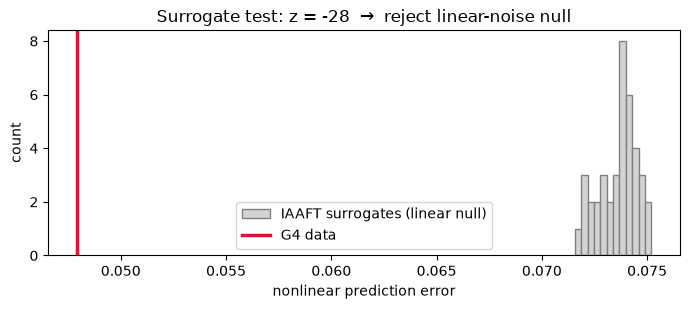

In [8]:
st = ts.surrogate_test(freq, statistic="prediction_error", method="iaaft", n=39, seed=1)
sd = st.to_dict()
print(f"data prediction error   : {sd['data_statistic']:.4f}")
print(f"surrogate mean          : {np.mean(sd['surrogate_statistics']):.4f}")
print(f"z-score                 : {sd['z_score']:.1f}")
print(f"null rejected?          : {sd['rejected']}   (p = {sd['p_value']})")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(sd["surrogate_statistics"], bins=12, color="lightgray", edgecolor="gray",
        label="IAAFT surrogates (linear null)")
ax.axvline(sd["data_statistic"], color="crimson", lw=2.5, label="G4 data")
ax.set(xlabel="nonlinear prediction error", ylabel="count",
       title=f"Surrogate test: z = {sd['z_score']:.0f}  →  reject linear-noise null")
ax.legend()
fig.tight_layout()
plt.show()

The data (crimson) predicts **enormously** better than any surrogate — a z-score of order −30.
This is decisive: G4's wobble is **not** a linear stochastic process. It is deterministic.

### Recurrence quantification (RQA)

A final, orthogonal confirmation. On the *embedded* trajectory, a recurrence plot marks when the
state returns near a past state. Deterministic dynamics produce long **diagonal lines** (high
determinism DET); noise produces isolated dots.

determinism  DET = 0.991   (near 1 => deterministic)
laminarity   LAM = 0.995
avg diagonal line = 12.7 samples (long-on-average lines => strong determinism)


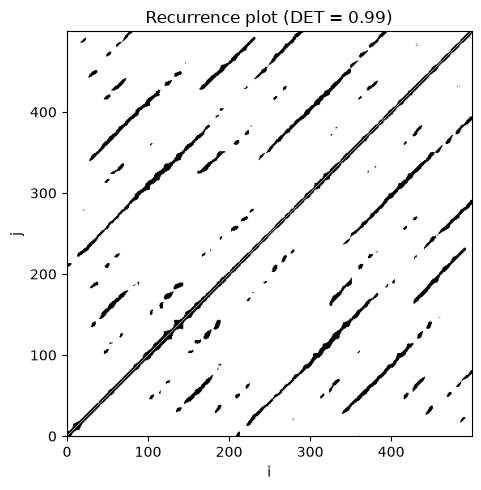

In [9]:
rq = ts.rqa(Ym, recurrence_rate=0.05)      # run RQA on the m-dim embedding
rd = rq.to_dict()
print(f"determinism  DET = {rd['determinism']:.3f}   (near 1 => deterministic)")
print(f"laminarity   LAM = {rd['laminarity']:.3f}")
print(f"avg diagonal line = {rd['avg_diagonal_length']:.1f} samples "
      f"(long-on-average lines => strong determinism)")
# NB: max_diagonal_length here is ~N (the whole series recurring once over the record) — an
# embedding-length artifact, not evidence. DET (the fraction of recurrences that fall on diagonals)
# is the real determinism argument, so we lead with DET and the *average* line length.

# recurrence plot on a window (full matrix is huge; a window shows the texture)
rm = ts.recurrence_matrix(Ym[:500], recurrence_rate=0.05)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rm.matrix.toarray(), cmap="binary", origin="lower")
ax.set(xlabel="i", ylabel="j", title=f"Recurrence plot (DET = {rd['determinism']:.2f})")
fig.tight_layout()
plt.show()

> ### 🔎 Act I verdict
> Delay embedding → a **structured, low-dimensional attractor** ($m\approx5$, $D_2\approx2.2$);
> Kantz → a **positive Lyapunov exponent** ($\lambda_1\approx0.08$/s); the surrogate test
> **rejects the linear-noise null** at $z\approx-30$; RQA → **DET $\approx$ 0.99**.
> Every independent probe agrees: **G4's wobble is low-dimensional deterministic chaos**, a
> controllable instability of a few degrees of freedom — *not* irreducible randomness. Good news:
> deterministic means *modellable*, and modellable means *controllable*.

---
## Act II — The model & the map of safety

We adopt the mechanistic swing-equation model `GridNode`. First we *validate* it against the
data, then we use it to draw the **map of safety** — where in state space a fault still returns
to synchrony, and where it triggers a blackout.

### Sanity check: the model reproduces Act I's chaos

Under strong periodic load modulation ($A=0.9$, $\Omega=0.6$) the pendulum rattles chaotically.
We confirm a positive Lyapunov exponent and that a **stroboscopic section** (sampling once per
forcing period $T=2\pi/\Omega$) matches the folded shape we reconstructed from the data.

model Lyapunov spectrum: [ 0.119 -0.319]  /s
lambda_1 = 0.119 /s  (positive, ~ matches the data's 0.08)


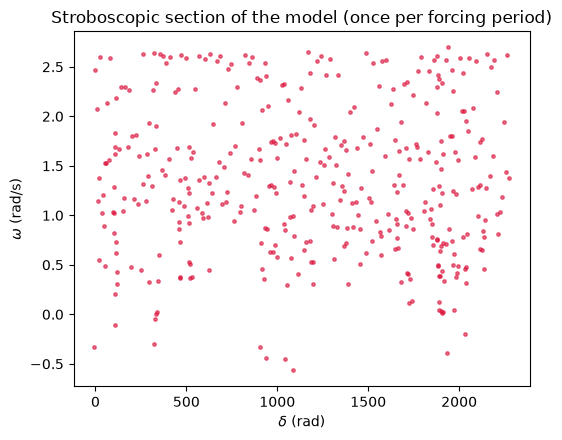

In [10]:
driven = GridNode(params={"P": 0.2, "A": 0.9, "Omega": 0.6, "alpha": 0.2})
exps = driven.lyapunov_spectrum(final_time=300.0, dt=0.02)
print("model Lyapunov spectrum:", np.round(exps, 3), " /s")
print(f"lambda_1 = {exps[0]:.3f} /s  (positive, ~ matches the data's {lam1:.2f})")

sm = ts.StroboscopicMap(driven, 2 * np.pi / 0.6)
sec = sm.trajectory(400)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(sec.y[:, 0], sec.y[:, 1], s=6, color="crimson", alpha=0.6)
ax.set(xlabel=r"$\delta$ (rad)", ylabel=r"$\omega$ (rad/s)",
       title="Stroboscopic section of the model (once per forcing period)")
fig.tight_layout()
plt.show()

The model produces its own strange attractor with $\lambda_1\approx0.12$/s — the same order as
the data. The mechanistic model is a faithful stand-in. Now we ask the safety question.

### Fixed points of the autonomous machine

Turn off the forcing ($A=0$). At load $P$ the synchronized state is the stable node
$\delta^*=\arcsin(P/K)$; there is also an **unstable saddle** at $\pi-\delta^*$ marking the
edge of the potential well. We find both with the analytic-Jacobian Newton solver.

In [11]:
auto = GridNode(params={"P": 0.4, "A": 0.0, "alpha": 0.2})
fps = ts.fixed_points(auto, region=Box(np.array([-np.pi, -2.0]), np.array([np.pi, 2.0])),
                      n_seeds=250)
for fp in fps:
    role = "STABLE node (synchronized)" if fp.stable else "UNSTABLE saddle (well edge)"
    print(f"delta = {fp.x[0]:+.3f} rad,  omega = {fp.x[1]:+.3f}  ->  {role}")
    print(f"    eigenvalues: {np.round(fp.eigenvalues, 3)}")
print(f"\nAnalytic check: delta* = arcsin(0.4) = {delta_star(0.4):.3f},  "
      f"saddle at pi - delta* = {np.pi - delta_star(0.4):.3f}")

delta = +0.412 rad,  omega = +0.000  ->  STABLE node (synchronized)
    eigenvalues: [-0.1+0.952j -0.1-0.952j]
delta = +2.730 rad,  omega = +0.000  ->  UNSTABLE saddle (well edge)
    eigenvalues: [ 0.863+0.j -1.063+0.j]

Analytic check: delta* = arcsin(0.4) = 0.412,  saddle at pi - delta* = 2.730


The stable node has **complex** eigenvalues (damped oscillatory recovery — the machine rings
back to sync); the saddle has real eigenvalues of opposite sign (one escape direction). The
saddle is the doorway to a blackout.

### Basins of attraction — the map of safety

Which initial faults return to synchrony, and which run away? We tessellate the
$(\delta,\omega)$ plane and integrate each cell (at a higher load $P=0.6$, closer to the limit).
Cells that reach the synchronized node are **safe**; cells whose angle runs away (pole slip) are
a **blackout**.

In [12]:
node6 = GridNode(params={"P": 0.6, "A": 0.0, "alpha": 0.2})
grid = Grid(np.array([-np.pi, -3.0]), np.array([np.pi, 5.0]), (80, 80))   # 80x80, within budget
basins = ts.basins_of_attraction(node6, grid, dt=0.2, max_steps=400)
sync_id = next(iter(basins.fractions))               # the one attractor label
print(f"synchronized basin fraction : {basins.fractions[sync_id]:.1%}")
print(f"diverged (blackout) fraction: {basins.diverged_fraction:.1%}")

synchronized basin fraction : 18.5%
diverged (blackout) fraction: 81.5%


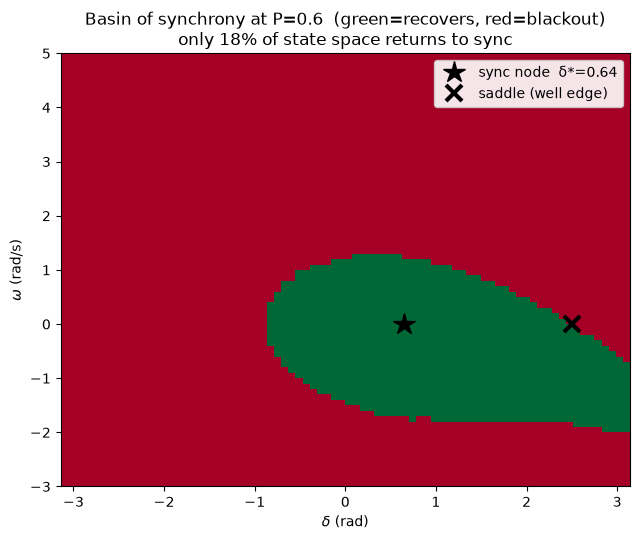

saved hero figure -> assets/img/capstone_basin_of_synchrony.png


In [13]:
# HERO FIGURE 1 — the basin of synchrony.
lo, hi = basins.grid.lo, basins.grid.hi
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(basins.labels.T, origin="lower", aspect="auto",
               extent=[lo[0], hi[0], lo[1], hi[1]],
               cmap="RdYlGn", interpolation="nearest")
# mark the operating point (the synchronized node) and the saddle
ds = delta_star(0.6)
ax.plot(ds, 0.0, "k*", ms=16, label=f"sync node  δ*={ds:.2f}")
ax.plot(np.pi - ds, 0.0, "kx", ms=11, mew=3, label="saddle (well edge)")
ax.set(xlabel=r"$\delta$ (rad)", ylabel=r"$\omega$ (rad/s)",
       title=f"Basin of synchrony at P=0.6  (green=recovers, red=blackout)\n"
             f"only {basins.fractions[sync_id]:.0%} of state space returns to sync")
ax.legend(loc="upper right", framealpha=0.9)
fig.tight_layout()
fig.savefig(f"{ASSETS}/capstone_basin_of_synchrony.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved hero figure -> assets/img/capstone_basin_of_synchrony.png")

The green island is safety; everything red is a blackout. Even at $P=0.6$ — well below the
nominal limit $K=1$ — **most of state space does not return to sync**. A large enough fault
throws the machine over the saddle and off the grid.

### Basin stability (Menck) & resilience (Halekotte–Feudel)

Menck et al. (2013) quantify safety as the **fraction of random perturbations** that return to
sync — a global, nonlinear robustness measure the classical eigenvalue misses. Resilience adds
the *distance* from the operating point to the basin boundary: how big a shove it can take.

In [14]:
bf = ts.basin_fractions(node6, Box(np.array([-np.pi, -3.0]), np.array([np.pi, 5.0])),
                        n=1500, dt=0.2, max_steps=400, seed=0)
bfd = bf.to_dict()
print(f"basin stability (Menck)  : {list(bfd['fractions'].values())[0]:.1%} of faults resync")
print(f"blackout fraction        : {bfd['diverged']:.1%}")

res_val = ts.resilience(basins, sync_id).value
print(f"resilience (dist to edge): {res_val:.2f}  (state-space units to the basin boundary)")

basin stability (Menck)  : 19.7% of faults resync
blackout fraction        : 80.3%
resilience (dist to edge): 1.16  (state-space units to the basin boundary)


> ### 🔎 Act II verdict
> The model reproduces the observed chaos. The synchronized state is a stable node
> ($\delta^*\approx0.41$, complex eigenvalues) shadowed by an unstable saddle at $\pi-\delta^*$.
> At $P=0.6$ only **~20%** of faults return to sync — the machine has a *finite, quantifiable*
> safety margin, and "losing sync" means being kicked over the saddle into the runaway set.
> A single eigenvalue would call this "stable"; basin stability reveals it is only *marginally* so.

---
## Act III — The warning & the verdict

Now the sister unit's blackout. The stress-test log shows the operator slowly raising the load
$P$ under demand noise until the machine slipped a pole. Could it have been **seen coming**?

27230 samples, dt = 0.10 s, span = 2723 s
load ramp: P from 0.550 to 1.004


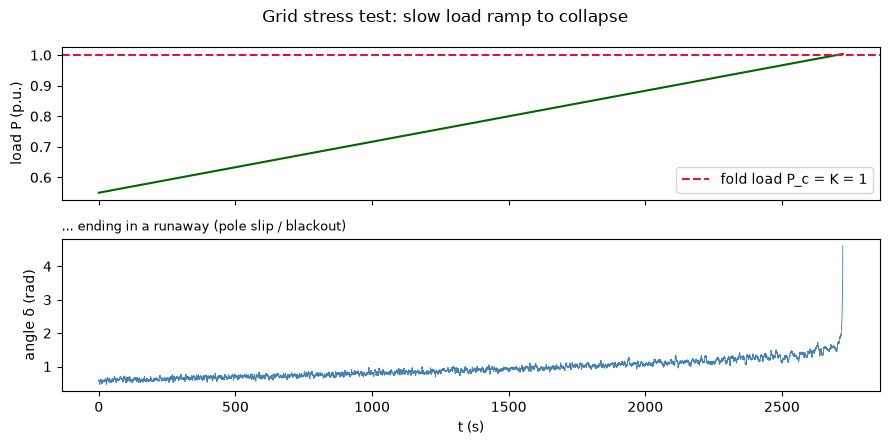

In [15]:
stress = pd.read_csv(f"{DATA}/stress_test.csv", comment="#")
ts_t = stress["t"].values
P = stress["load_P"].values
angle = stress["angle"].values
print(f"{len(stress)} samples, dt = {np.median(np.diff(ts_t)):.2f} s, span = {ts_t[-1]:.0f} s")
print(f"load ramp: P from {P.min():.3f} to {P.max():.3f}")

fig, axes = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True)
axes[0].plot(ts_t, P, color="darkgreen")
axes[0].axhline(critical_load(), color="crimson", ls="--", label="fold load P_c = K = 1")
axes[0].set(ylabel="load P (p.u.)"); axes[0].legend(loc="lower right")
axes[1].plot(ts_t, angle, color="steelblue", lw=0.6)
axes[1].set(xlabel="t (s)", ylabel="angle δ (rad)")
axes[1].set_title("... ending in a runaway (pole slip / blackout)", loc="left", fontsize=9)
fig.suptitle("Grid stress test: slow load ramp to collapse")
fig.tight_layout()
plt.show()

### Early-warning signals: critical slowing down

Near a fold the restoring stiffness $\kappa=K\cos\delta^*\to0$: the potential well flattens,
recovery slows, and noise-driven fluctuations **grow and become more correlated**. We detrend the
angle by its quasi-static operating point $\delta^*(P)$, then track a rolling **variance** and
**lag-1 autocorrelation** — the two canonical EWS.

In [16]:
# residual about the moving operating point (delta* is nan past the fold P>K -> mask those)
ds_track = np.array([delta_star(p) for p in P])
resid = angle - ds_track
finite = np.isfinite(resid)

W = 400   # rolling window (samples)
resid_s = pd.Series(resid)
roll_var = resid_s.rolling(W).var().values

def _ac1(a):
    a = a - a.mean()
    v = np.dot(a, a)
    return np.dot(a[:-1], a[1:]) / v if v > 0 else 0.0

roll_ac1 = resid_s.rolling(W).apply(_ac1, raw=True).values

v0 = np.nanmean(roll_var[(P >= 0.55) & (P < 0.7)])
v1 = np.nanmean(roll_var[(P >= 0.95) & (P < 1.0)])
print(f"rolling variance  early (P~0.6): {v0:.4f}   late (P~0.97): {v1:.4f}   (x{v1 / v0:.1f} rise)")

rolling variance  early (P~0.6): 0.0017   late (P~0.97): 0.0056   (x3.2 rise)


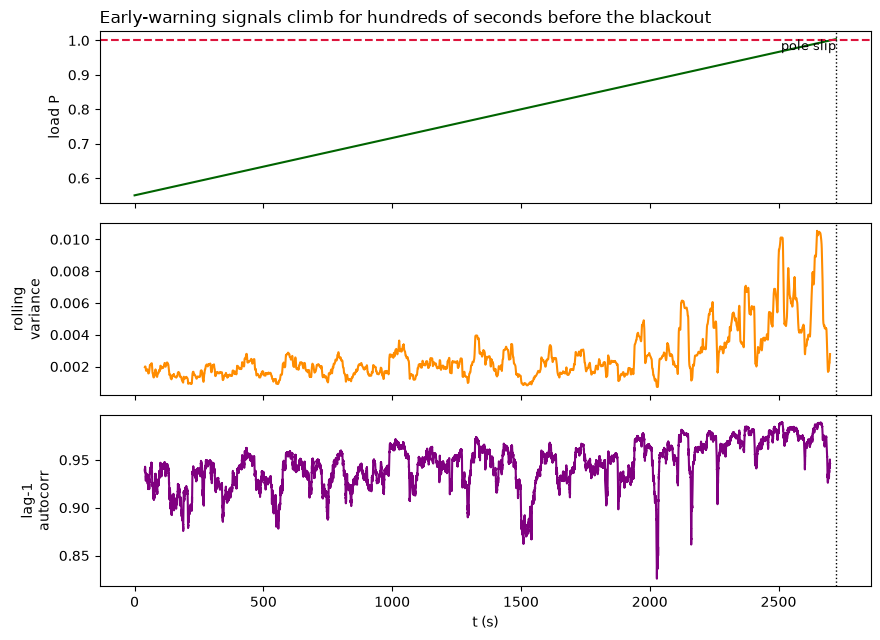

saved hero figure -> assets/img/capstone_ews_rising_variance.png


In [17]:
# HERO FIGURE 2 — rising-variance early-warning signal.
fig, axes = plt.subplots(3, 1, figsize=(9, 6.5), sharex=True)
axes[0].plot(ts_t, P, color="darkgreen")
axes[0].axhline(1.0, color="crimson", ls="--")
axes[0].set(ylabel="load P")
axes[0].set_title("Early-warning signals climb for hundreds of seconds before the blackout",
                  loc="left")
axes[1].plot(ts_t, roll_var, color="darkorange")
axes[1].set(ylabel="rolling\nvariance")
axes[2].plot(ts_t, roll_ac1, color="purple")
axes[2].set(xlabel="t (s)", ylabel="lag-1\nautocorr")
# mark the actual blackout: the pole slip at the end of the record, where the angle crosses the
# saddle (delta ~ pi) and runs away. (NOT the P=K fold crossing, and NOT where delta*(P) stops
# being finite — that masking boundary is an artifact of the detrend, not the collapse.)
t_collapse = ts_t[-1]
for ax in axes:
    ax.axvline(t_collapse, color="k", ls=":", lw=1)
axes[0].text(t_collapse, P.max(), " pole slip", va="top", ha="right", fontsize=9)
fig.tight_layout()
fig.savefig(f"{ASSETS}/capstone_ews_rising_variance.png", dpi=110, bbox_inches="tight")
plt.show()
print("saved hero figure -> assets/img/capstone_ews_rising_variance.png")

Both the variance and the lag-1 autocorrelation **rise as $P\to K$** — textbook critical slowing
down. The alarm was ringing long before the blackout.

### Windowed RQA confirms the regime change

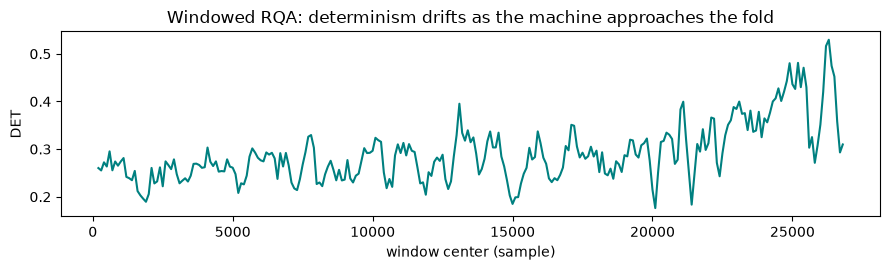

In [18]:
wr = ts.windowed_rqa(resid[finite], window=400, step=100, recurrence_rate=0.05)
# wr.results is one RQAResult per window center; pull the determinism series.
det_series = np.array([r.to_dict()["determinism"] for r in wr.results])
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(wr.centers, det_series, color="teal")
ax.set(xlabel="window center (sample)", ylabel="DET",
       title="Windowed RQA: determinism drifts as the machine approaches the fold")
fig.tight_layout()
plt.show()

### Why it slows down — the mechanism (the model's eigenvalue)

The EWS are not magic: they are the shadow of a real eigenvalue collapsing. For the (overdamped)
machine, the synchronized node's **leading eigenvalue** has real part $\to0$ as $P\to K$, so the
recovery time $\tau=1/|\mathrm{Re}\,\lambda|$ **diverges**.

recovery time  tau(P=0.2) = 2.1 s   ->   tau(P=0.99) = 14.3 s


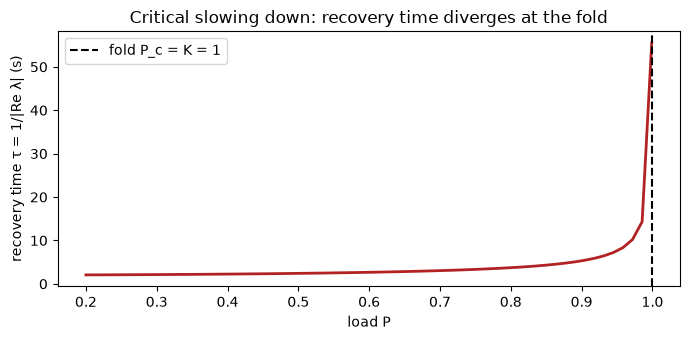

In [19]:
Pgrid = np.linspace(0.2, 0.999, 60)
recov = np.array([-1.0 / leading_eigenvalue(p, alpha=2.5).real for p in Pgrid])
print(f"recovery time  tau(P=0.2) = {recov[0]:.1f} s   ->   tau(P=0.99) = {recov[-2]:.1f} s")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(Pgrid, recov, color="firebrick", lw=2)
ax.axvline(1.0, color="k", ls="--", label="fold P_c = K = 1")
ax.set(xlabel="load P", ylabel="recovery time τ = 1/|Re λ| (s)",
       title="Critical slowing down: recovery time diverges at the fold")
ax.legend()
fig.tight_layout()
plt.show()

The recovery time blows up from ~2 s to tens of seconds as $P\to K$ — *this* is the mechanism
behind the rising variance. Slow recovery + constant demand noise = ballooning fluctuations.

### The point of no return — continuation & tipping point

Finally we track the synchronized attractor as $P$ increases and find where it **ceases to
exist**. `continuation` re-finds and matches attractors across the load ramp; `tipping_points`
reads off where the synchronized set annihilates — the saddle-node fold.

In [20]:
cont_node = GridNode(params={"alpha": 0.3, "A": 0.0})
cont = ts.continuation(cont_node, "P", np.linspace(0.2, 1.15, 40),
                       Box(np.array([-np.pi, -3.0]), np.array([np.pi, 5.0])),
                       dt=0.2, max_steps=300, n=800)
tp = ts.tipping_points(cont)
items = tp.to_dict()["items"]
Pc = items[0]["value"]
print(f"tipping event: synchronized attractor '{items[0]['attractor']}' "
      f"{items[0]['kind']}s at P_c = {Pc:.3f}")
print(f"analytic fold:  P_c = K = {critical_load():.3f}   ->  match!")

# map P_c back to a time in the stress log
idx = int(np.argmin(np.abs(P - Pc)))
print(f"the operator crossed P_c ≈ {Pc:.2f} at t ≈ {ts_t[idx]:.0f} s "
      f"(collapse recorded at t ≈ {t_collapse:.0f} s)")

tipping event: synchronized attractor '1' disappears at P_c = 1.004
analytic fold:  P_c = K = 1.000   ->  match!
the operator crossed P_c ≈ 1.00 at t ≈ 2723 s (collapse recorded at t ≈ 2723 s)


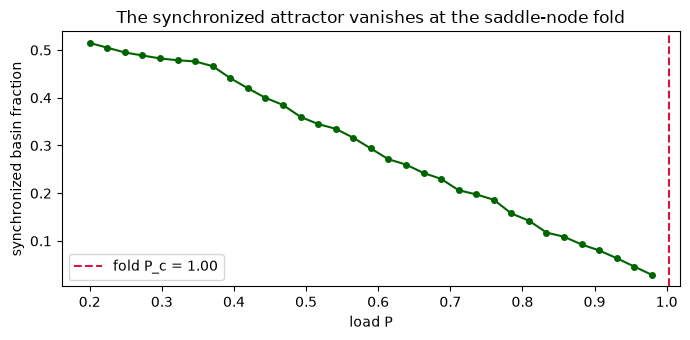

In [21]:
# Show the synchronized basin fraction collapsing to zero at the fold.
# cont.fractions maps each attractor id -> its basin fraction across the P sweep.
sync_frac = np.asarray(cont.fractions[items[0]["attractor"]], dtype=float)
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(cont.values, sync_frac, "o-", color="darkgreen", ms=4)
ax.axvline(Pc, color="crimson", ls="--", label=f"fold P_c = {Pc:.2f}")
ax.set(xlabel="load P", ylabel="synchronized basin fraction",
       title="The synchronized attractor vanishes at the saddle-node fold")
ax.legend()
fig.tight_layout()
plt.show()

---
## ✅ Final verdict — Guardian of the Grid

**1. Is G4's wobble deterministic or noise?**
**Deterministic low-dimensional chaos.** Five independent probes concur: a structured
reconstructed attractor ($m\approx5$, $D_2\approx2.2$), a positive Lyapunov exponent
($\lambda_1\approx0.08$/s, Lyapunov time ~12 s), a surrogate test that rejects the linear-noise
null at $z\approx-30$, and RQA determinism $\approx0.99$. The wobble is a *controllable*
instability of a few degrees of freedom — not irreducible randomness.

**2. How much safety margin, and what does losing sync look like?**
The swing equation has a stable synchronized node shadowed by an unstable saddle. At $P=0.6$ only
**~20%** of state space returns to sync (Menck basin stability); "losing sync" is being kicked
over the saddle into the runaway (pole-slip) set. The margin is *finite and quantifiable* — and
a naive single-eigenvalue check would overstate it.

**3. Could the blackout have been seen coming — and where is the point of no return?**
**Yes.** Rolling variance and lag-1 autocorrelation of the detrended angle **climbed for
hundreds of seconds** before the collapse — critical slowing down. The mechanism is the
synchronized node's leading eigenvalue collapsing to zero (recovery time diverging from ~2 s to
tens of seconds). Continuation places the **saddle-node fold at $P_c \approx 1.00 = K$**; the
operator crossed it, and the machine slipped a pole shortly after.

### Recommendations to the operator
- **Keep load below a margin of $P_c = K$.** The fold is at the line limit; do not ride the edge.
- **Watch the rolling variance of the angle residual as a live alarm.** It rose measurably long
  before the fault — a cheap, model-free early-warning signal.
- **Stretch goal:** raising the grid coupling $K$ (stronger transmission) or the damping $\alpha$
  (droop control / inertia) pushes the fold out and *enlarges the basin of synchrony* — the two
  physical levers for a more resilient grid. Re-run Act II/III with a larger $K$ or $\alpha$ to
  see the safe island grow and the tipping load move up.

*Case closed.* The tools that diagnosed a single noisy channel, built and validated a mechanistic
model, mapped its safety, and located the point of no return are exactly the `tsdynamics`
workflow you practised across Modules 02–07.